# PatchCore Lite Baseline

In [1]:
from pathlib import Path
import sys

ROOT = Path.cwd().resolve()
if not (ROOT / "src").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))


In [2]:
INSTALL_DEPS = False

if INSTALL_DEPS:
    import subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-r", str(ROOT / "requirements.txt")])


In [3]:
from src.common.config import load_config
from src.common.data import SpacepressoDataModule
from src.common.evaluation import evaluate_predictions
from src.common.paths import resolve_path
from src.common.ranking import RankingWriter, validation_ranking_record
from src.common.seed import set_seed
from src.common.submission import SubmissionWriter, validate_submission
from src.common.training import ExperimentRunner
from src.common.validation import make_validation_split
from src.common.visualization import show_predictions
from src.methods import get_method_class


In [4]:
config_path = ROOT / "configs/patchcore_lite/juan_baseline.yaml"
config = load_config(config_path)

local_data = ROOT / "data" / "spacepresso"
if local_data.exists():
    config["data"]["root"] = str(local_data)

config["data"]["load_images"] = False
config["ranking"]["output_path"] = str(resolve_path(config["ranking"]["output_path"], ROOT))
config["submission"]["output_path"] = str(resolve_path(config["submission"]["output_path"], ROOT))

set_seed(config.get("seed", 42))
config


{'seed': 42,
 'experiment': {'name': 'patchcore_lite_baseline',
  'owner': 'juan',
  'output_dir': 'outputs/juan/patchcore_lite_baseline'},
 'data': {'root': 'C:\\Users\\sjuan\\Desktop\\Spacespresso\\data\\spacepresso',
  'image_size': 224,
  'load_images': False},
 'method': {'name': 'patchcore_lite',
  'backbone': 'wide_resnet50_2',
  'batch_size': 4,
  'out_indices': [2, 3],
  'coreset_fraction': 0.01,
  'candidate_pool_size': 6000,
  'max_coreset_size': 2000,
  'projection_dim': 512,
  'bank_chunk_size': 2048,
  'sigma': 4.0},
 'training': {'enabled': True, 'mode': 'fit_memory_bank'},
 'validation': {'metric': 'pixel_ap',
  'n_splits': 5,
  'fold': 0,
  'good_fraction': 0.25,
  'anomaly_fraction': 1.0},
 'ranking': {'output_path': 'C:\\Users\\sjuan\\Desktop\\Spacespresso\\outputs\\validation_rankings.csv'},
 'submission': {'output_path': 'C:\\Users\\sjuan\\Desktop\\Spacespresso\\submissions\\juan\\patchcore_lite_baseline.csv'}}

In [5]:
dm = SpacepressoDataModule(**config["data"])

train_good = dm.load_train_good()
train_anomalies = dm.load_train_anomalies()
test = dm.load_test()

print("classes:", dm.list_classes())
print("train_good:", len(train_good))
print("train_anomalies:", len(train_anomalies))
print("test:", len(test))

assert train_good
assert train_anomalies
assert test


classes: ['class_01', 'class_02', 'class_03', 'class_04', 'class_05', 'class_06', 'class_07', 'class_08']
train_good: 19005
train_anomalies: 235
test: 5910


In [6]:
validation = config["validation"]
validation_split = make_validation_split(
    train_good=train_good,
    train_anomalies=train_anomalies,
    n_splits=validation["n_splits"],
    fold=validation["fold"],
    seed=config.get("seed", 42),
    good_fraction=validation.get("good_fraction", 1.0),
    anomaly_fraction=validation.get("anomaly_fraction", 1.0),
)

print("fit images:", len(validation_split.train_good))
print("validation images:", len(validation_split.val_samples))


fit images: 15190
validation images: 1190


In [7]:
Method = get_method_class(config["method"]["name"])
runner = ExperimentRunner(Method(config), config)
runner.fit(validation_split.train_good)

val_predictions = runner.predict(validation_split.val_samples)
val_metrics = evaluate_predictions(validation_split.val_samples, val_predictions).as_dict()
val_metrics


Using PatchCore backbone: wide_resnet50_2
Fitting PatchCore memory bank for class_01: 2080 images


PatchCore feature extraction:   0%|          | 0/520 [00:00<?, ?it/s]

Greedy coreset:   0%|          | 0/1999 [00:00<?, ?it/s]

Seen bank: 1,630,720 patches x 1536 dims; candidate pool: 6,000 patches; coreset: 2,000 patches
Fitting PatchCore memory bank for class_02: 1705 images


PatchCore feature extraction:   0%|          | 0/427 [00:00<?, ?it/s]

...

PatchCore inference:   0%|          | 0/37 [00:00<?, ?it/s]

PatchCore inference:   0%|          | 0/35 [00:00<?, ?it/s]

PatchCore inference:   0%|          | 0/42 [00:00<?, ?it/s]

PatchCore inference:   0%|          | 0/38 [00:00<?, ?it/s]

{'pixel_ap': 0.3225628961586067,
 'image_ap': 0.5815740720664708,
 'pixel_auroc': 0.9238425059325163,
 'image_auroc': 0.8020563662693551,
 'n_images': 1190,
 'n_anomaly_pixels': 1217489}

In [8]:
record = validation_ranking_record(
    config=config,
    metrics=val_metrics,
    validation_config=validation,
    model_id=config["experiment"]["name"],
    source="baseline",
    config_path=config_path.relative_to(ROOT),
    notes="PatchCore Lite baseline validation",
)

ranking = RankingWriter(config["ranking"]["output_path"]).upsert(record)
ranking.head(10)


C:\Users\sjuan\Desktop\Spacespresso\src\common\ranking.py:95: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat([existing, incoming], ignore_index=True)


,rank,model_id,experiment_name,parent_experiment,owner,method,source,metric,score,pixel_ap,...,n_images,n_anomaly_pixels,validation_n_splits,validation_folds,validation_good_fraction,validation_anomaly_fraction,config_path,params_json,notes,created_at
0,1,patchcore_lite_baseline,patchcore_lite_baseline,,juan,patchcore_lite,baseline,pixel_ap,0.322563,0.322563,...,1190,1217489,5,0,0.25,1.0,configs\patchcore_lite\juan_baseline.yaml,"{""backbone"": ""wide_resnet50_2"", ""bank_chunk_si...",PatchCore Lite baseline validation,2026-05-07T12:46:02.757469+00:00


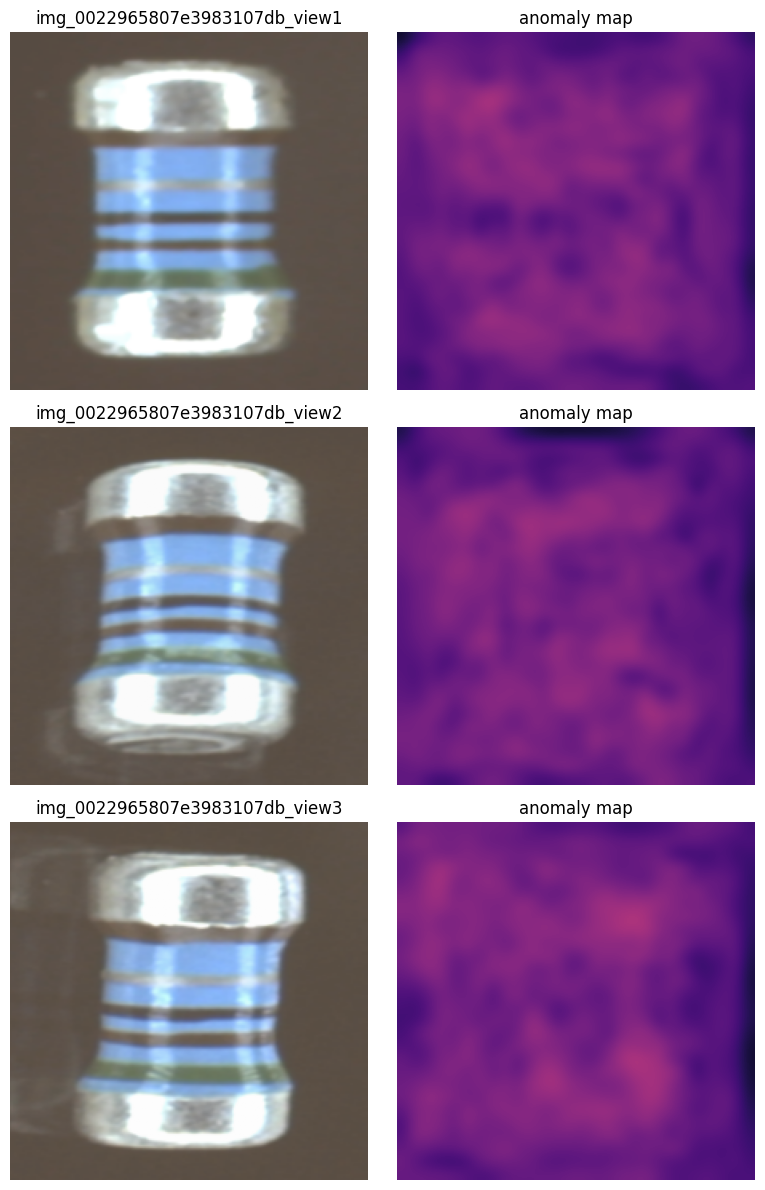

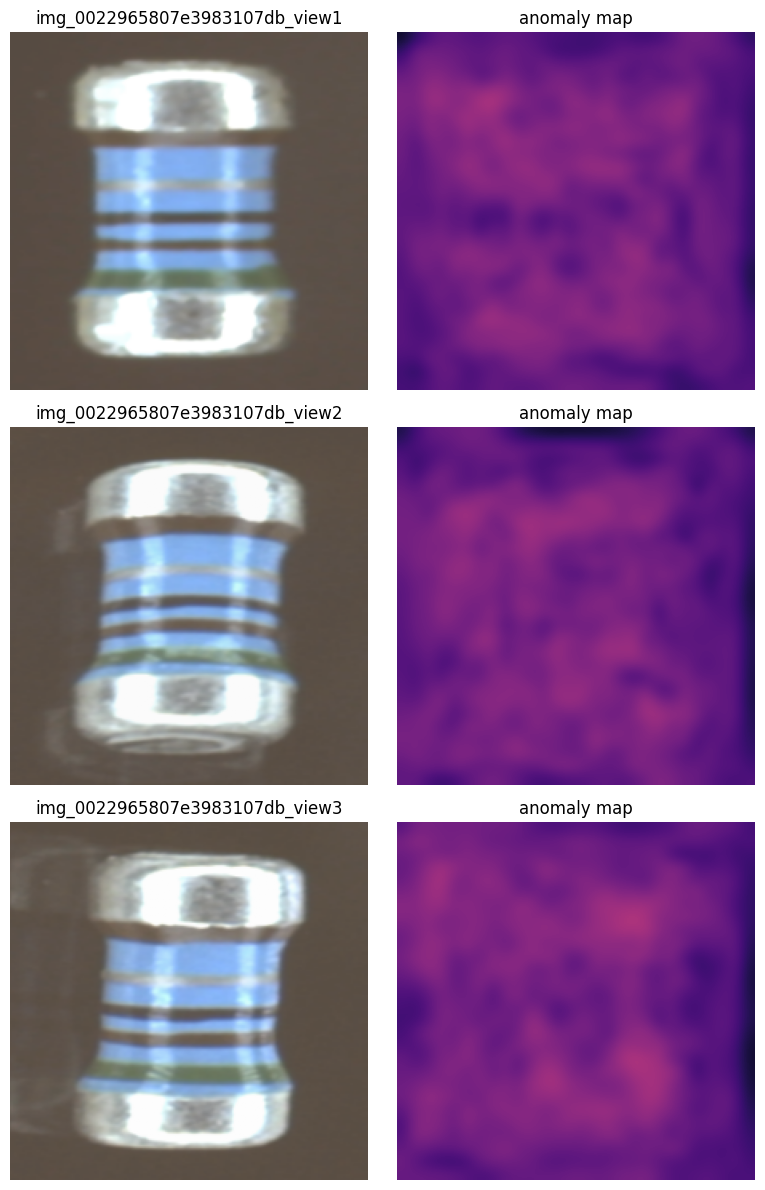

In [9]:
show_predictions(validation_split.val_samples, val_predictions, n=3)


In [10]:
RUN_TEST_SUBMISSION = False

if RUN_TEST_SUBMISSION:
    final_runner = ExperimentRunner(Method(config), config)
    final_runner.fit(train_good)
    test_predictions = final_runner.predict(test)
    output_path = SubmissionWriter(config["submission"]["output_path"]).write(test_predictions)
    image_size = config["data"]["image_size"]
    expected_shape = (image_size, image_size) if isinstance(image_size, int) else tuple(image_size)
    validate_submission(output_path, expected_shape=expected_shape)
    output_path
